In [4]:
# not so intuitive abbreviations:
# .CP = CellPop in use
# .SD = Standard Deviation
# .EE = Everything else
# .SM = Signaling molecules

# Setup

In [5]:
#essential reticulate functions (must run first)
Sys.setenv(RETICULATE_PYTHON="/home/luca/anaconda3/envs/reticulate/bin/python")
library(reticulate)
reticulate::use_python("/home/luca/anaconda3/envs/reticulate/bin/python")
reticulate::use_condaenv("/home/luca/anaconda3/envs/reticulate")
reticulate::py_module_available(module='anndata') #needs to be TRUE
reticulate::import('anndata') #good to make sure this doesn't error

[1] TRUE

Module(anndata)

In [6]:
pacman::p_load(dplyr, stringr, data.table, tidyr,plyr,logr,
               pheatmap, colorRamps, gridExtra, ggplot2, ggrepel, RColorBrewer, ComplexHeatmap,
               Rmagic, phateR, parallel,gridExtra,ggplot2, ggpubr, ggrepel, ggbreak, gridExtra, patchwork, grid, ggh4x,
               Seurat, harmony)

In [7]:
Combine.Seurat = "/nfs/lab/projects/CellCrosstalk/npod.pancreas/Final/Assets/20230518_RNA_FiltMin20exceptBetaLate_CellChat_nPODids.SCT.rds.SM.RDS"
Seurat.name = "20230518_RNA_FiltMin20exceptBetaLate_CellChat_nPODids.SCT.rds.SM.RDS"
assets.dir = "/nfs/lab/projects/CellCrosstalk/npod.pancreas/Final/Assets/"
cc.db = "/nfs/lab/projects/islet_multiomics_stress/analysis/CellChat/Assets/CellChatDB.human.txt"

options(stringsAsFactors = FALSE)
# start log
options("logr.on" = TRUE, "logr.notes" = TRUE)
options("logr.autolog" = TRUE)
options("logr.compact" = TRUE)
options("logr.traceback" = TRUE)
log.file = paste('/nfs/lab/projects/CellCrosstalk/npod.pancreas/Apr23/', Sys.Date(),".1_DefineExpressors.log", sep="")

In [8]:
assets.dir = "/nfs/lab/projects/CellCrosstalk/npod.pancreas/Final/Assets/"

SM.ls.df.dir = paste(assets.dir, "SM.ls.df.txt", sep = "")
cellpop.sample.fraction.dir = paste(assets.dir, "cellpop.sample.fraction.txt", sep = "")
cc.db = "/nfs/lab/projects/islet_multiomics_stress/analysis/CellChat/Assets/CellChatDB.human.txt"
gaulton.db = "/nfs/lab/Luca/Assets/LR.Database/Gaulton.db.V1_Curated_TMP.txt"


options(stringsAsFactors = FALSE)

In [9]:
Endocrine = c('Alpha', 'Beta', 'Delta')
Exocrine = c('Acinar1_2_6','Acinar_3','Acinar_4','Acinar_5','Ductal','MUC5b_Ductal')
Immune = c('Tcells','Bcells', 'Macrophage','Mast')
Endothelial = c('Endothelial', 'LymphEndo')
Stromal = c('Activated_Stellate','Quiescent_Stellate')

gaps.compartments = c(3, 9, 13, 15)

cell.pop.order = c(Endocrine, Exocrine, Immune, Endothelial, Stromal)
# Reverse order, if needed
rev.cell.pop.order = c(rev(Stromal), rev(Endothelial), rev(Immune), rev(Exocrine), rev(Endocrine), use.names = TRUE)


colors.compartments = c('Endocrine'='#26bfbf',
           'Exocrine'='#ed872d',
           'Immune'='#3F98E0',
           'Endothelial'='#800080',
           'Stromal'='#F5DE6C')

# conditions
condition.ls <- c("ND", "Aab", "earlyT1D", "lateT1D")


# Colors
colors.conditions = c("ND" = "#85EF1B",
                      "Aab" = "#EFEF1B",
                      "earlyT1D" = "#EF851B",
                      "lateT1D" = "#EF1B1B")

In [10]:
# Load condition fraction

In [11]:
# Load sample fraction
cellpop.sample.fraction = read.table(cellpop.sample.fraction.dir, sep = "\t", stringsAsFactors = F, header = T)

# Load SM DBs

In [12]:
# Load list of ligands and receptors
SM.ls.df = read.table(SM.ls.df.dir, sep = "\t", stringsAsFactors = F, header = T)
SM.ls = unique(SM.ls.df$gene)
length(SM.ls)

[1] 857

In [13]:
# Load database
cc.db.data = read.table(cc.db, sep = "\t", stringsAsFactors = F, header = T)
# cc.db.data = cc.db.data[,c(11,2,3)]
message("CCDB number of interactions: ", length(levels(factor(cc.db.data$interaction_name))))

CCDB number of interactions: 1939



In [14]:
# Load and prepare Gaulton DB
gaulton.db = "/nfs/lab/Luca/Assets/LR.Database/Gaulton.db.V1_Curated_TMP.txt"
gaulton.db.data = read.table(gaulton.db, sep = "\t", stringsAsFactors = F, header = T)
gaulton.db.data = gaulton.db.data[,c(2,3,4)]
colnames(gaulton.db.data)[1] = "gene"
SM.ls.df.GDB = merge(SM.ls.df, gaulton.db.data, by = "gene", all.x = TRUE)
SM.ls.df.GDB[is.na(SM.ls.df.GDB)] <- ""
# Calculate category sizes
categories.size = SM.ls.df.GDB[SM.ls.df.GDB$Type == "Ligand",]
categories.size = data.frame(table(categories.size$Signaling))
colnames(categories.size) = c("Signaling", "Signaling.size")

# Order signaling
secreted.signaling.order = c('cytokines','COMPLEMENT','Immune.mods',
'Growth.factors', 'Developmental.proteins',
'Enzymes', 'enzyme.modulator','neuropeptides','Hormones')

In [15]:
# Make a list of all ligands
ligands.ls = c(unique(cc.db.data$ligand), 
              str_split_fixed(unique(cc.db.data$ligand[grepl("_", cc.db.data$ligand)]), "_", n = 2)[,1],
              str_split_fixed(unique(cc.db.data$ligand[grepl("_", cc.db.data$ligand)]), "_", n = 2)[,2])
ligands.ls = unique(ligands.ls)
ligands.ls = ligands.ls[ligands.ls %in% SM.ls]
# Make a list of all receptors
receptors.ls = c(unique(cc.db.data$receptor),
                 str_split_fixed(unique(cc.db.data$receptor[grepl("_", cc.db.data$receptor)]), "_", n = 2)[,1],
                 str_split_fixed(unique(cc.db.data$receptor[grepl("_", cc.db.data$receptor)]), "_", n = 2)[,2])
receptors.ls = unique(receptors.ls)
receptors.ls = receptors.ls[receptors.ls %in% SM.ls]

# Make a list of all receptors that are also ligands
both = ligands.ls[ligands.ls %in% receptors.ls]
message("Number of ligands that are also receptors: ", length(both))


# Exclude those from the other lists
receptors.ls = receptors.ls[!receptors.ls %in% both]
message("Number of receptors: ", length(receptors.ls))


# Exclude those from the other lists
ligands.ls = ligands.ls[!ligands.ls %in% both]
message("Number of ligands: ", length(ligands.ls))


#Check that the length is 860
message("Final Number of SM: ", length(ligands.ls) + length(receptors.ls) + length(both))

Number of ligands that are also receptors: 54

Number of receptors: 379

Number of ligands: 424

Final Number of SM: 857



# Corrected matrix

## By sample - Ligands

In [16]:
means.mat.summary = read.table(paste(assets.dir, "corrected.means.mat.bysampleV2.txt", sep = ""))

In [17]:
# count ligands per celltype
means.mat.summary = means.mat.summary[means.mat.summary$expressor == TRUE,]
means.mat.summary = merge(means.mat.summary, SM.ls.df.GDB, by = "gene", all.x = TRUE)
means.mat.summary = means.mat.summary[!means.mat.summary$Type == "Receptor", ]
means.mat.summary = means.mat.summary[!means.mat.summary$Type == "Both", ]
message("Check that Receptors are not showing up :")
levels(factor(means.mat.summary$Type))

Check that Receptors are not showing up :



[1] "Ligand"

In [18]:
means.mat.summary = data.frame(table(means.mat.summary$cellpop, means.mat.summary$gene))
colnames(means.mat.summary) = c("cellpop", "gene", "Frequency")
means.mat.summary$cellpop = factor(means.mat.summary$cellpop, levels = rev.cell.pop.order)


In [19]:
markers = c("INS", "GCG", "SST", "PRSS2", "TNF", "GRN", "SPP1", "OPN")
#markers = c("INSR", "GCGR", "SSTR", "PARD3", "SORT1", "TNFRSF1A", "TNFRSF1B")
markers.data = means.mat.summary[means.mat.summary$gene %in% markers, ]
markers.data = markers.data[markers.data$Frequency != 0, ]
markers.data$gene = factor(markers.data$gene, levels = markers)

Warning message:
“Duplicated aesthetics after name standardisation: colour”
Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


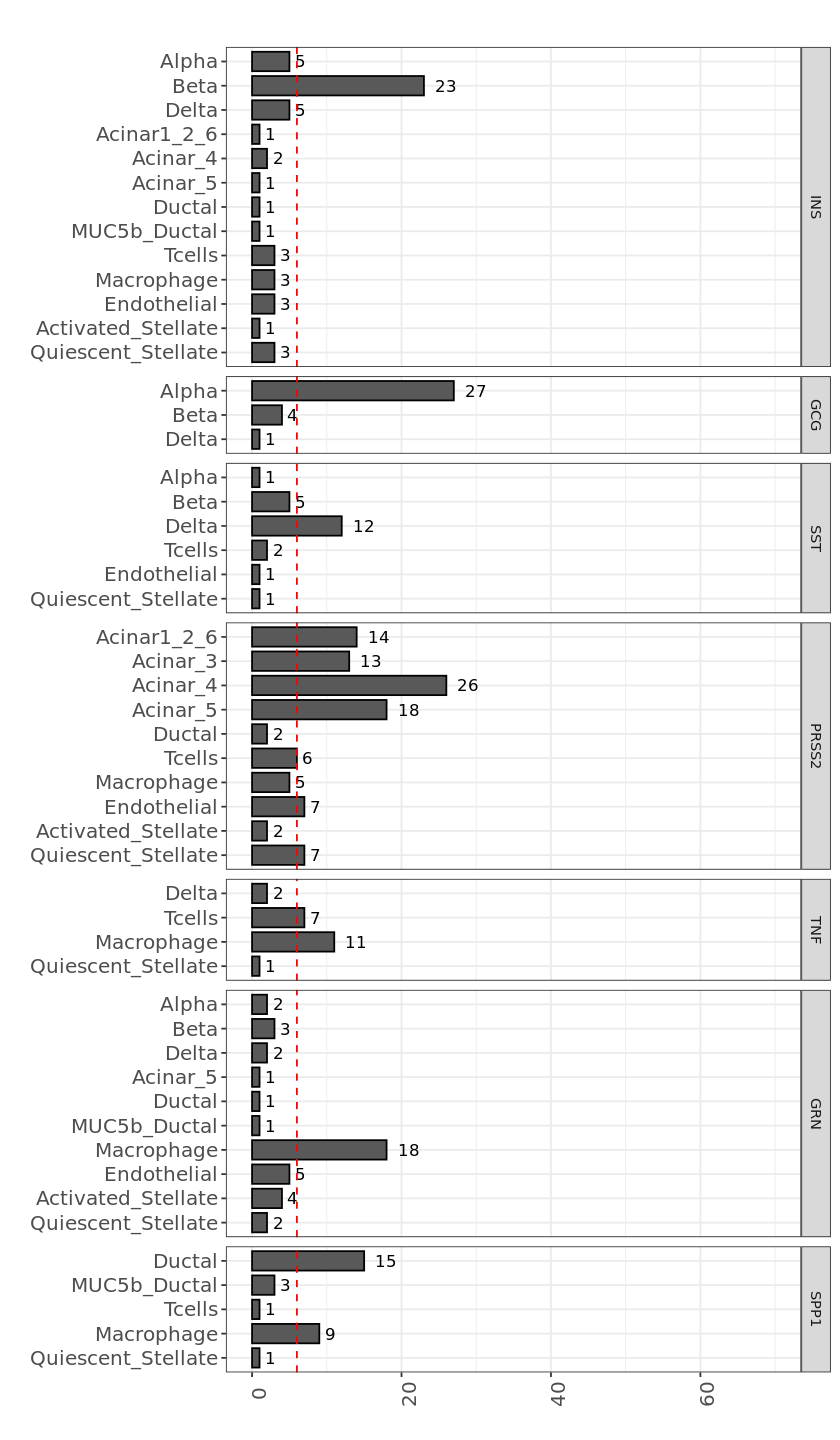

In [20]:
options(repr.plot.width=7, repr.plot.height=12)
ggplot(markers.data, aes(x= cellpop, y = Frequency, group = cellpop, label = Frequency)) +
       theme_bw () +
       geom_bar(stat="identity", colour="black", width = 0.8, 
                position = position_dodge(width = 0.8), colour="black") +
       labs(y= "", x = "", title = paste(""))+
       ylim(0,70)+
       theme(axis.text = element_text(size = 12), axis.title = element_text(size = 12, face = "bold"),
                  axis.text.x = element_text(angle = 90),
                             plot.title = element_text(size = 18, face = "bold", , hjust = 0.5)) +
coord_flip()+
geom_text(hjust = - 0.5, size = 3.5, position = position_dodge(width = 0.8)) +
geom_hline(yintercept = 6, color="red", linetype="dashed", size=0.5)+
facet_grid(gene ~. , scales = "free_y", space = "free_y")

In [21]:
# If we would put a threshold that would be higher than 6 samples
## This would avoid hormone cross-contamination

In [22]:
# Treshold plot
Freq.tresh = 6

In [23]:
threshold.plot = as.data.frame(table(means.mat.summary$cellpop, means.mat.summary$Frequency > Freq.tresh))
colnames(threshold.plot) = c("cellpop", "Frequency.conditions", "Frequency.aggregated")
threshold.plot$cellpop = factor(threshold.plot$cellpop, levels = rev.cell.pop.order)
## remove the 0 frequency.condition
threshold.plot = threshold.plot[!threshold.plot$Frequency.conditions == 0, ]
threshold.plot = threshold.plot[threshold.plot$Frequency.conditions == TRUE, ]
#threshold.plot$Frequency.conditions = factor(threshold.plot$Frequency.conditions, levels = rev(c("1","2","3","4")))

Warning message:
“Duplicated aesthetics after name standardisation: colour”


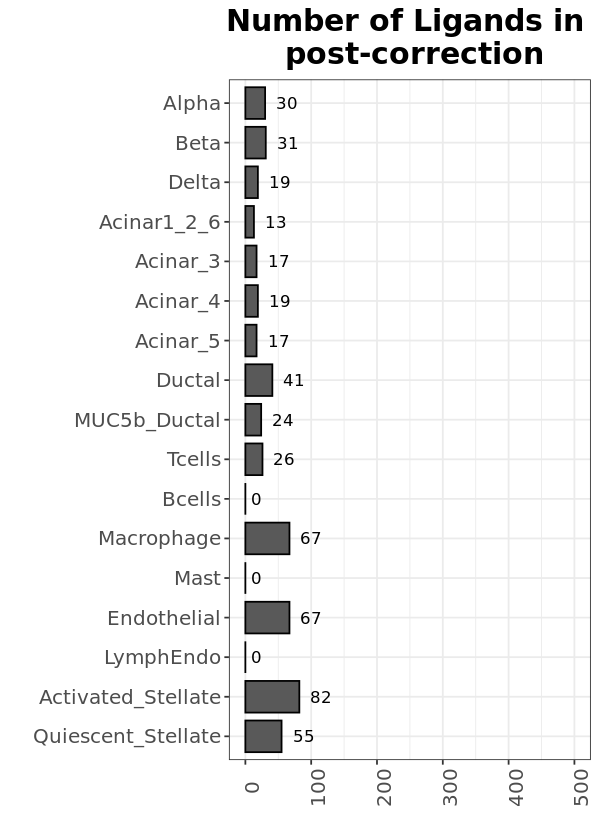

In [24]:
options(repr.plot.width=5, repr.plot.height=7)
ggplot(threshold.plot, aes(x= cellpop, y = Frequency.aggregated, label = Frequency.aggregated)) +
       theme_bw () +
       geom_bar(stat="identity", colour="black", width = 0.8, 
                position = position_dodge(width = 0.8), colour="black") +
       labs(y= "", x = "", title = paste("Number of Ligands in \n post-correction"))+
       ylim(0,500)+
       theme(axis.text = element_text(size = 12), axis.title = element_text(size = 12, face = "bold"),
                  axis.text.x = element_text(angle = 90),
                             plot.title = element_text(size = 18, face = "bold", , hjust = 0.5)) +
coord_flip()+
geom_text(hjust = - 0.5, size = 3.5, position = position_dodge(width = 0.8)) # requires the labels aes

In [25]:
# Save list of expressors/ligand
means.mat.summary.l = means.mat.summary[means.mat.summary$Frequency > Freq.tresh,]
head(means.mat.summary.l)

,cellpop,gene,Frequency
,<fct>,<fct>,<int>
7,Beta,ADCYAP1,23
19,Activated_Stellate,ADGRE5,11
25,Macrophage,ADGRE5,19
27,Quiescent_Stellate,ADGRE5,8
28,Tcells,ADGRE5,13
47,Activated_Stellate,ADM,19


## By sample fraction

In [26]:
means.mat.summary.sample.fraction = merge(means.mat.summary, cellpop.sample.fraction, by = "cellpop")
#means.mat.summary.sample.fraction$expr.50pt = means.mat.summary.sample.fraction$Frequency > means.mat.summary.sample.fraction$tresh_50pct
#means.mat.summary.sample.fraction$expr.25pt = means.mat.summary.sample.fraction$Frequency >= means.mat.summary.sample.fraction$tresh_25pct

test = means.mat.summary.sample.fraction[means.mat.summary.sample.fraction$gene == "INS", ]

message("> PCT50")
test$cellpop[test$Frequency >= test$tresh_50pct]
message(">= PCT25")
test$cellpop[test$Frequency >= test$tresh_25pct]
message(">= PCT20")
test$cellpop[test$Frequency >= test$tresh_20pct]
message(">= PCT10")
test$cellpop[test$Frequency >= test$tresh_10pct]

> PCT50



[1] Beta
17 Levels: Quiescent_Stellate Activated_Stellate LymphEndo Endothelial ... Alpha

>= PCT25



[1] Beta  Delta
17 Levels: Quiescent_Stellate Activated_Stellate LymphEndo Endothelial ... Alpha

>= PCT20



[1] Beta   Delta  Tcells
17 Levels: Quiescent_Stellate Activated_Stellate LymphEndo Endothelial ... Alpha

>= PCT10



[1] Alpha              Beta               Delta              Endothelial       
[5] Macrophage         Quiescent_Stellate Tcells            
17 Levels: Quiescent_Stellate Activated_Stellate LymphEndo Endothelial ... Alpha

In [28]:
#I am choosing 10% because I will anyways blacklist

In [29]:
threshold.plot = as.data.frame(table(means.mat.summary.sample.fraction$cellpop, 
        means.mat.summary.sample.fraction$Frequency >= means.mat.summary.sample.fraction$tresh_10pct))
colnames(threshold.plot) = c("cellpop", "Frequency.conditions", "Frequency.aggregated")
threshold.plot$cellpop = factor(threshold.plot$cellpop, levels = rev.cell.pop.order)
## remove the 0 frequency.condition
threshold.plot = threshold.plot[!threshold.plot$Frequency.conditions == 0, ]
threshold.plot = threshold.plot[threshold.plot$Frequency.conditions == TRUE, ]
#threshold.plot$Frequency.conditions = factor(threshold.plot$Frequency.conditions, levels = rev(c("1","2","3","4")))

Warning message:
“Duplicated aesthetics after name standardisation: colour”


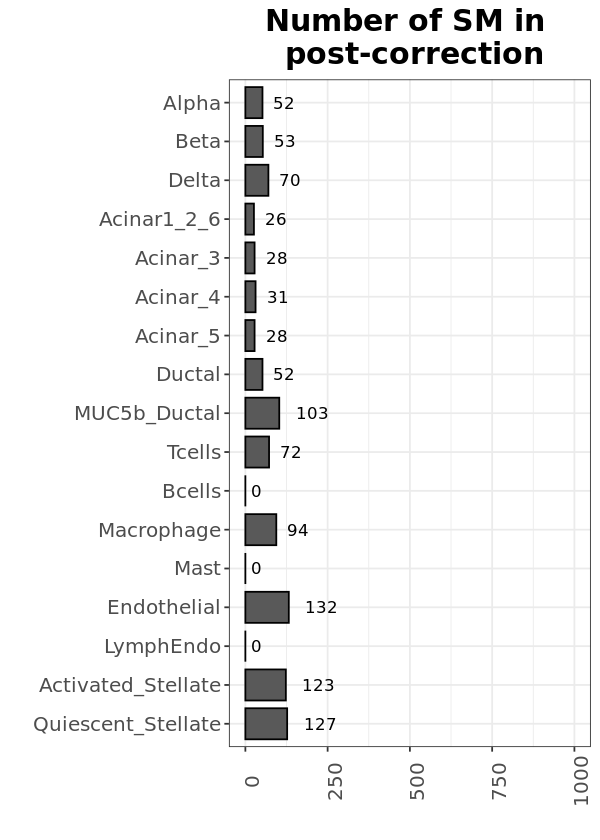

In [30]:
options(repr.plot.width=5, repr.plot.height=7)
ggplot(threshold.plot, aes(x= cellpop, y = Frequency.aggregated, label = Frequency.aggregated)) +
       theme_bw () +
       geom_bar(stat="identity", colour="black", width = 0.8, 
                position = position_dodge(width = 0.8), colour="black") +
       labs(y= "", x = "", title = paste("Number of SM in \n post-correction"))+
       ylim(0,1000)+
       theme(axis.text = element_text(size = 12), axis.title = element_text(size = 12, face = "bold"),
                  axis.text.x = element_text(angle = 90),
                             plot.title = element_text(size = 18, face = "bold", , hjust = 0.5)) +
coord_flip()+
geom_text(hjust = - 0.5, size = 3.5, position = position_dodge(width = 0.8)) # requires the labels aes

In [31]:
# Save list of expressors/ligand
means.mat.summary.l = means.mat.summary.sample.fraction[means.mat.summary.sample.fraction$Frequency >= means.mat.summary.sample.fraction$tresh_10pct,]
expressors = means.mat.summary.l[,c(1,2,3)]
head(expressors)

,cellpop,gene,Frequency
,<fct>,<fct>,<int>
18,Acinar_3,GDF15,5
48,Acinar_3,ANGPTL4,12
77,Acinar_3,SEMA5A,4
96,Acinar_3,KITLG,12
118,Acinar_3,APP,16
132,Acinar_3,AREG,4


In [32]:
nrow(expressors[expressors$cellpop == "Beta",])
nrow(expressors[expressors$cellpop == "Macrophage",])

[1] 53

[1] 94

In [33]:
# Yes, all good

In [34]:
# Print out expressors
write.table(expressors, paste(assets.dir, "expressors.bysample.txt", sep = ""), 
            sep = "\t", row.names = T, col.names = T)